In [1683]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic-df/Titanic.csv


In [1684]:
df = pd.read_csv('/kaggle/input/titanic-df/Titanic.csv')

In [1685]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [1686]:
categorical_cols = df.select_dtypes(include=['object']).columns
label_encoders = {}

In [1687]:
from sklearn.preprocessing import LabelEncoder
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [1688]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,108,1,22.0,1,0,523,7.2500,147,2
1,2,1,1,190,0,38.0,1,0,596,71.2833,81,0
2,3,1,3,353,0,26.0,0,0,669,7.9250,147,2
3,4,1,1,272,0,35.0,1,0,49,53.1000,55,2
4,5,0,3,15,1,35.0,0,0,472,8.0500,147,2
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,548,1,27.0,0,0,101,13.0000,147,2
887,888,1,1,303,0,19.0,0,0,14,30.0000,30,2
888,889,0,3,413,0,NaN,1,2,675,23.4500,147,2
889,890,1,1,81,1,26.0,0,0,8,30.0000,60,0


In [1689]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    int64  
 4   Sex          891 non-null    int64  
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    int64  
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    int64  
 11  Embarked     891 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 83.7 KB


In [1690]:
df['Age'].fillna(df['Age'].median(),inplace=True)

/tmp/ipykernel_30/1527141296.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)


In [1691]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [1692]:
df['Age'].unique()

array([22.  , 38.  , 26.  , 35.  , 28.  , 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  ,  8.  ,
       19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  , 49.  ,
       29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  , 16.  ,
       25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  , 71.  ,
       37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 , 51.  ,
       55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  , 45.5 ,
       20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  , 60.  ,
       10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  , 70.  ,
       24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

Modeling

A100 - 2m

In [1693]:
#ANALYSIS

<Axes: >

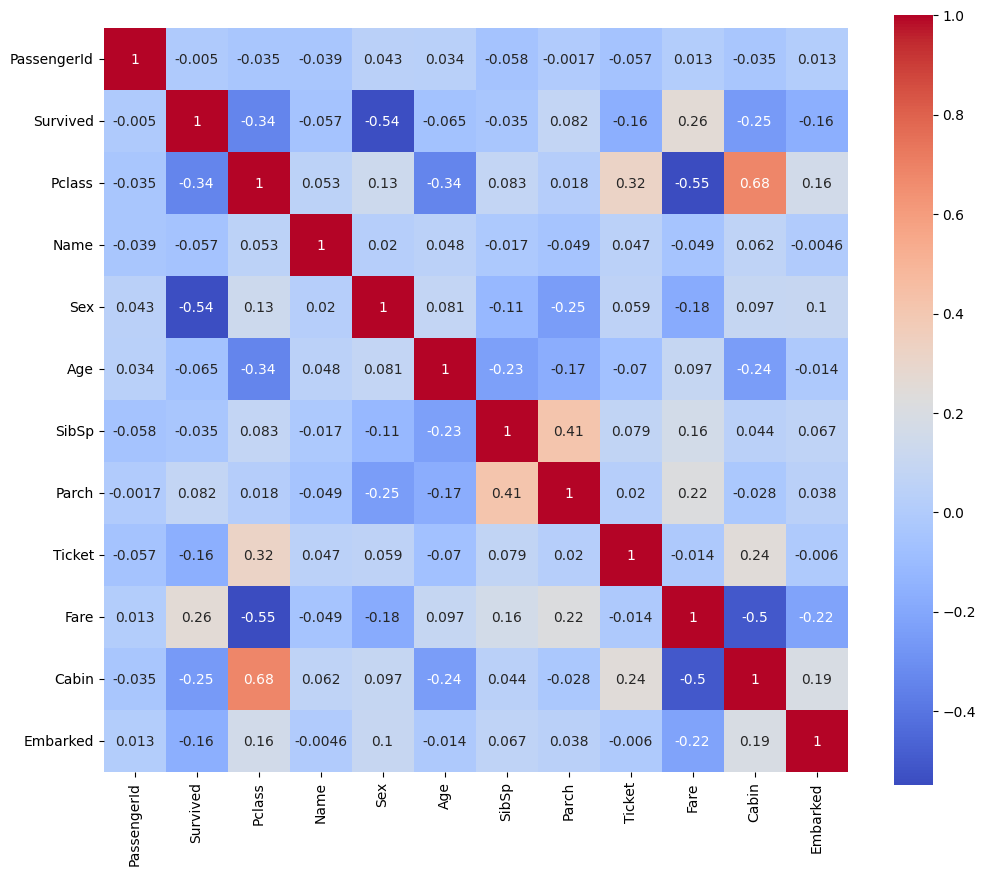

In [1694]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', square=True)

df

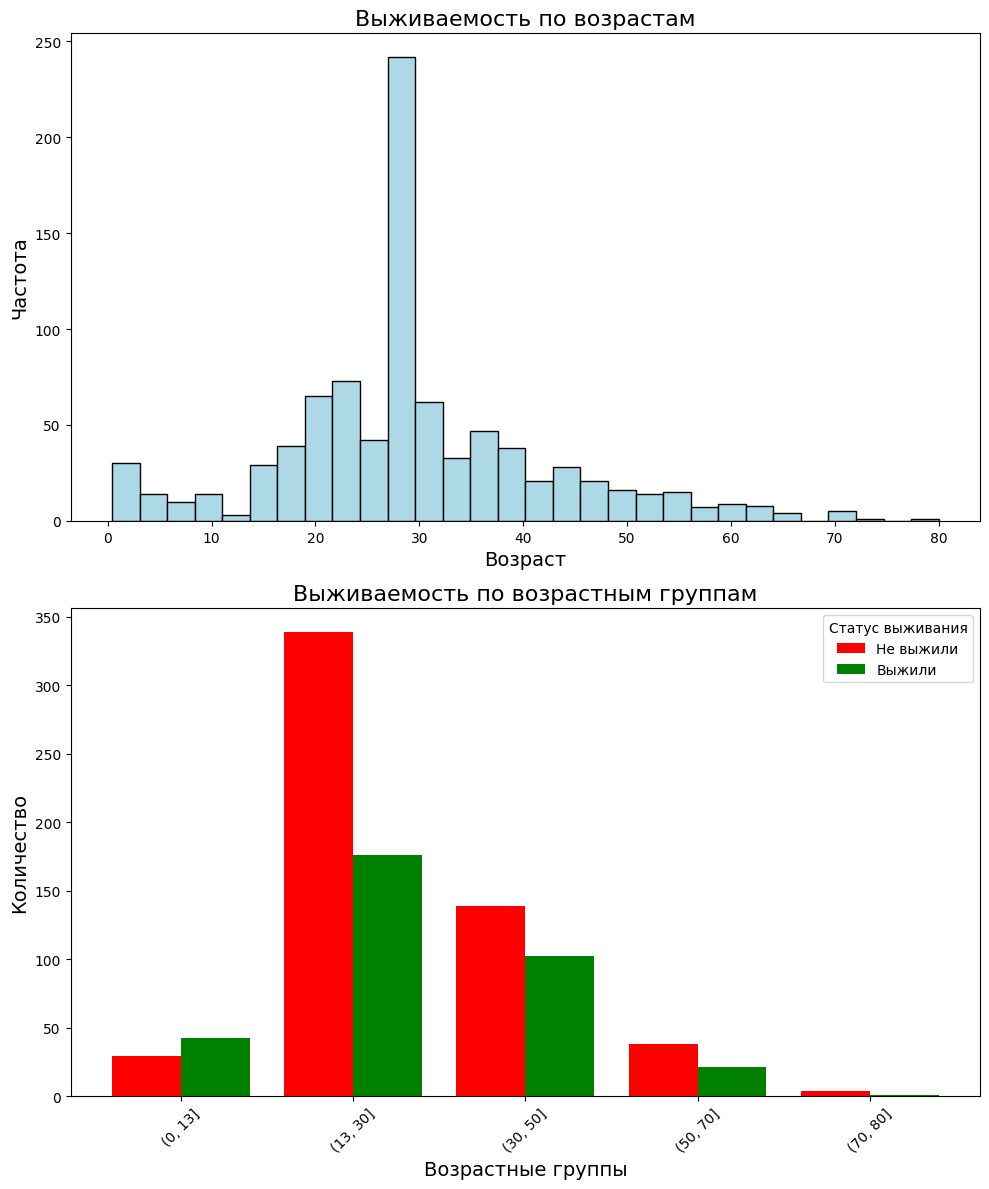

In [1695]:
#Age graphics
#1 график
age_survived = pd.pivot_table(
    df,
    index=pd.cut(df['Age'], bins=[0, 13, 30, 50, 70, 80]),
    columns='Survived',
    values='Age',
    aggfunc='count',
    observed=False,
    fill_value=0
)

age_survived.columns = ['Не выжили', 'Выжили']
age_survived.reset_index(inplace=True)

fig, axs = plt.subplots(2, 1, figsize=(10, 12))

axs[0].hist(df['Age'], bins=30, color='lightblue', edgecolor='black')
axs[0].set_xlabel('Возраст', fontsize=14)
axs[0].set_ylabel('Частота', fontsize=14)
axs[0].set_title('Выживаемость по возрастам', fontsize=16)

x_index = range(len(age_survived))
bar_width = 0.4
axs[1].bar(x_index, age_survived['Не выжили'], width=bar_width, color='red', label='Не выжили', align='center')
axs[1].bar([p + bar_width for p in x_index], age_survived['Выжили'], width=bar_width, color='green', label='Выжили', align='center')
axs[1].set_title('Выживаемость по возрастным группам', fontsize=16)
axs[1].set_xlabel('Возрастные группы', fontsize=14)
axs[1].set_ylabel('Количество', fontsize=14)
axs[1].legend(title='Статус выживания')
axs[1].set_xticks([p + bar_width / 2 for p in x_index])
axs[1].set_xticklabels(age_survived['Age'].astype(str), rotation=45)

# Показать графики
plt.tight_layout()
plt.show()
###Первая гипотеза

<Figure size 1000x600 with 0 Axes>

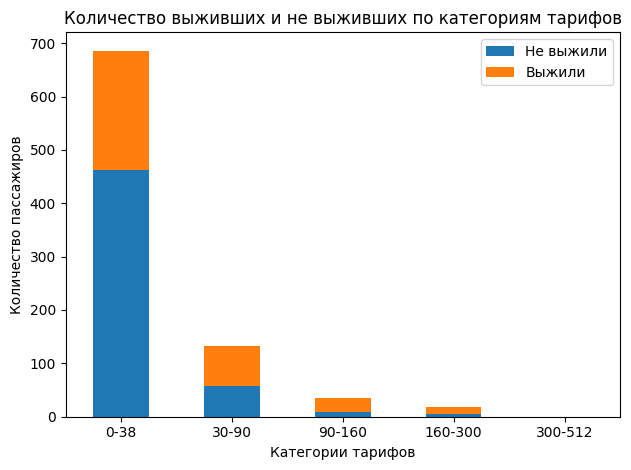

In [1696]:
fare_bins = [0, 38, 90, 160, 300, 512]
fare_labels = ['0-38', '30-90', '90-160', '160-300', '300-512']

fare_survived = pd.pivot_table(
    df,
    index=pd.cut(df['Fare'], bins=fare_bins, labels=fare_labels),
    columns='Survived',
    values='PassengerId',
    aggfunc='count',
    observed=False,
    fill_value=0
)
plt.figure(figsize=(10, 6))
fare_survived.plot(kind='bar', stacked=True)

plt.title('Количество выживших и не выживших по категориям тарифов')
plt.xlabel('Категории тарифов')
plt.ylabel('Количество пассажиров')
plt.xticks(rotation=0)
plt.legend(['Не выжили', 'Выжили'])

# Показ графика
plt.tight_layout()
plt.show()

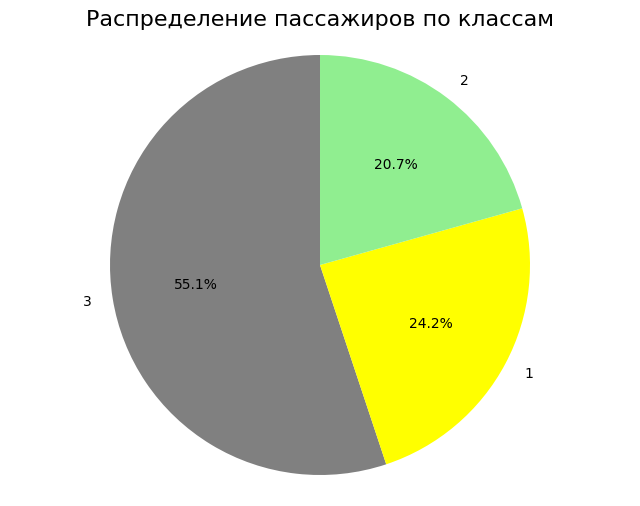

In [1697]:
pclass_counts = df['Pclass'].value_counts()

# Создаем круговую диаграмму
plt.figure(figsize=(8, 6))
plt.pie(pclass_counts, 
        labels=pclass_counts.index, 
        autopct='%1.1f%%', 
        startangle=90,    
        colors=['gray', 'yellow', 'lightgreen'])

plt.title('Распределение пассажиров по классам', fontsize=16)
plt.axis('equal')
plt.show()

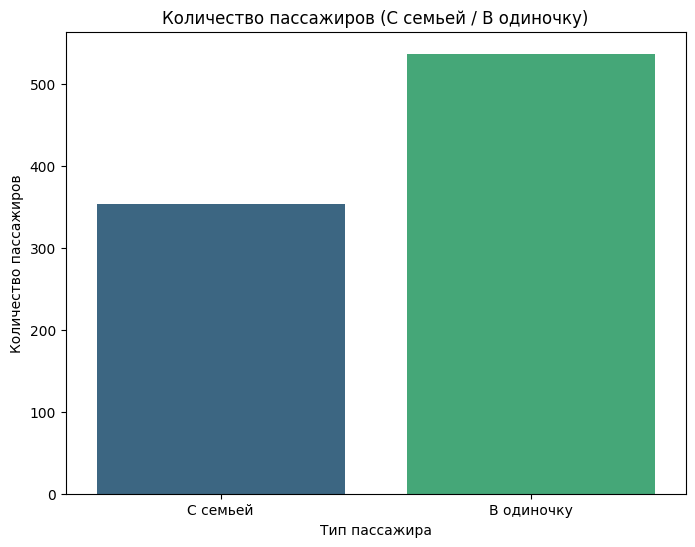

In [1698]:
plt.figure(figsize=(8, 6))
sns.countplot(x=(df['SibSp'] + df['Parch'] == 0).astype(int), 
               palette='viridis')

# Настройка меток
plt.xticks([0, 1], ['С семьей', 'В одиночку'])
plt.title('Количество пассажиров (С семьей / В одиночку)')
plt.xlabel('Тип пассажира')
plt.ylabel('Количество пассажиров')
plt.show()

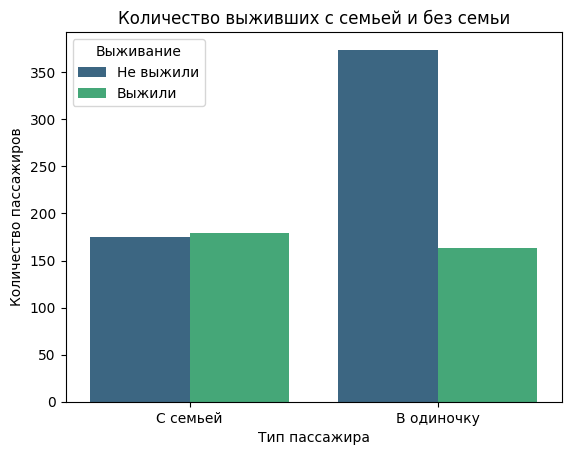

In [1699]:
sns.countplot(x=(df['SibSp'] + df['Parch'] == 0).astype(int),
              hue=df['Survived'], 
              palette='viridis')

# Настройка меток
plt.xticks([0, 1], ['С семьей', 'В одиночку'])
plt.title('Количество выживших с семьей и без семьи')
plt.xlabel('Тип пассажира')
plt.ylabel('Количество пассажиров')
plt.legend(title='Выживание', labels=['Не выжили', 'Выжили'])
plt.show()

In [1700]:
#FEATURE_ENGINEERING

In [1701]:
df.loc[df['Age'] < 13, 'Age'] = 1
# Присваиваем значение 2 для возраста от 13 до 30
df.loc[(df['Age'] > 13) & (df['Age'] < 30), 'Age'] = 2

# Присваиваем значение 3 для возраста от 30 до 50
df.loc[(df['Age'] > 30) & (df['Age'] < 50), 'Age'] = 3
df.loc[df['Age'] > 50, 'Age'] = 4


In [1702]:
#Делим на квантили
_fare = df['Fare']
q1,q2,q3 = _fare.quantile(0.25), _fare.quantile(0.5), _fare.quantile(0.75)
class_number = lambda x: 1 if x < q1 else 2 if x < q2 else 3 if x < q3 else 4
df['fare_class'] = list(map(class_number, _fare)) 

In [1703]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['is_alone'] = (df['FamilySize'] != 1).astype(int)

In [1704]:
n = 8
df['fare_bin'] = pd.cut(df['Fare'], n)
df = df.drop(['PassengerId', 'Ticket', 'Fare', 'fare_bin', 'Parch', 'SibSp'], axis=1)


In [1705]:
#feature_importances

In [1706]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Input
from sklearn.ensemble import RandomForestClassifier
from keras.regularizers import l2
from sklearn import metrics
from keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier, Pool

# # Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # # Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X.shape[0], len(y))

#Create the neural network model
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dropout(0.05))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)


#Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy:.2f}')



891 891
Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6824 - loss: 1.6442 - val_accuracy: 0.7972 - val_loss: 1.4149
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7908 - loss: 1.3686 - val_accuracy: 0.8392 - val_loss: 1.2048
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7659 - loss: 1.1999 - val_accuracy: 0.8531 - val_loss: 1.0535
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8167 - loss: 1.0690 - val_accuracy: 0.8392 - val_loss: 0.9401
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7977 - loss: 0.9574 - val_accuracy: 0.8392 - val_loss: 0.8478
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7980 - loss: 0.8730 - val_accuracy: 0.8392 - val_loss: 0.7745
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8057 - loss: 0.7796 - val_accuracy: 0.8392 - val_loss: 0.7194
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8220 - loss: 0.7202 - val_accuracy: 0.8462 - 

In [1707]:
#Используем классификатор случайный лес
RF = RandomForestClassifier(criterion='gini',
                                           n_estimators=1750,
                                           max_depth=7,
                                           min_samples_split=6,
                                           min_samples_leaf=6,
                                           oob_score=True,
                                           random_state=42,
                                           n_jobs=-1,
                                           verbose=1)
RF.fit(X_train, y_train)
y_pred_train = RF.predict(X_train)

y_pred_test = RF.predict(X_test)
accu = RF.score(X_train, y_train)
print( "Model Prediction Score", (accu * 100).round(2))
    


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 1750 out of 1750 | elapsed:    5.7s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed:    0.6s
[Parallel(n_jobs=4)]: Done 1750 out of 1750 | elapsed:    0.9s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent worker

Model Prediction Score 89.75


[Parallel(n_jobs=4)]: Done 1750 out of 1750 | elapsed:    0.9s finished


.pkl .h5 .gguf

In [1708]:
#Кэтбуст классификатор
catBoost = CatBoostClassifier(iterations = 250, depth=6, learning_rate=0.1)
pool = Pool(X_train, label=y_train)
pool_test = Pool(X_test)
catBoost.fit(pool)
y_A = catBoost.predict(pool_test)
print(accuracy_score(y_test, y_A))


0:	learn: 0.6343594	total: 1.42ms	remaining: 353ms
1:	learn: 0.5935062	total: 3.36ms	remaining: 416ms
2:	learn: 0.5510008	total: 4.9ms	remaining: 403ms
3:	learn: 0.5186348	total: 6.71ms	remaining: 412ms
4:	learn: 0.4901626	total: 8.31ms	remaining: 407ms
5:	learn: 0.4663751	total: 9.83ms	remaining: 400ms
6:	learn: 0.4490155	total: 11.4ms	remaining: 396ms
7:	learn: 0.4331147	total: 13ms	remaining: 392ms
8:	learn: 0.4215751	total: 14.5ms	remaining: 388ms
9:	learn: 0.4157366	total: 15.4ms	remaining: 369ms
10:	learn: 0.4018918	total: 16.8ms	remaining: 366ms
11:	learn: 0.3914063	total: 18.4ms	remaining: 366ms
12:	learn: 0.3898969	total: 19.2ms	remaining: 350ms
13:	learn: 0.3829584	total: 20.7ms	remaining: 348ms
14:	learn: 0.3751131	total: 22.1ms	remaining: 346ms
15:	learn: 0.3691969	total: 23.6ms	remaining: 345ms
16:	learn: 0.3676754	total: 24.5ms	remaining: 336ms
17:	learn: 0.3610163	total: 26ms	remaining: 335ms
18:	learn: 0.3562527	total: 27.4ms	remaining: 333ms
19:	learn: 0.3486647	total:

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


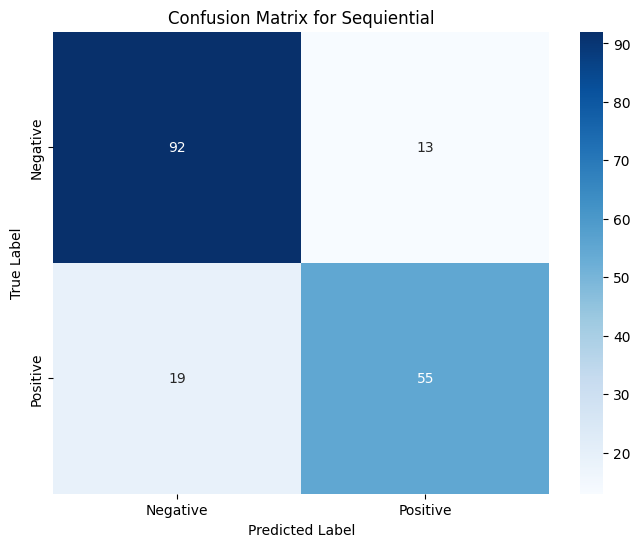

Accuracy: 0.82
Precision: 0.81
Recall: 0.74
F1 score: 0.76


In [1709]:
#Матрицы ошибок
y_pred_prob = model.predict(X_test)  # Вероятности предсказания
y_pred = (y_pred_prob > 0.5).astype(int)  # Бинарное преобразование
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
# Создаем матрицу ошибок
cm = confusion_matrix(y_test, y_pred)
# Визуализируем матрицу ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Sequiential')
plt.show()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)  
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")       
print(f"F1 score: {f1:.2f}") 

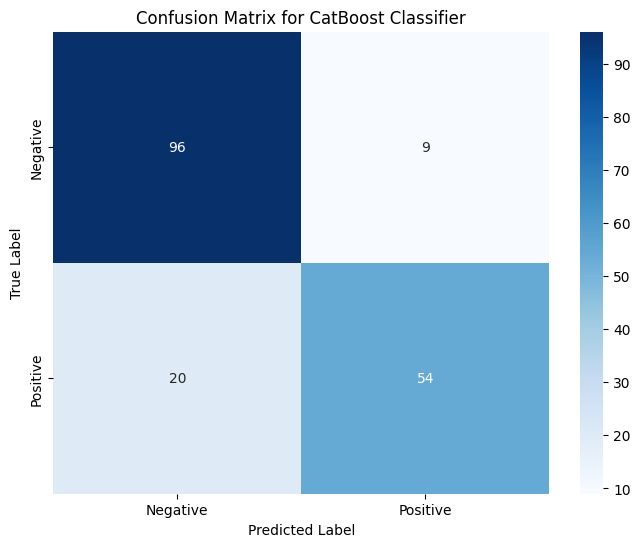

Accuracy: 0.82
Precision: 0.81
Recall: 0.74
F1 score: 0.76


In [1710]:
y_pred = catBoost.predict(X_test)

# Создание матрицы ошибок
cm = confusion_matrix(y_test, y_pred)

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for CatBoost Classifier')
plt.show()
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")       
print(f"F1 score: {f1:.2f}")


In [1711]:
from sklearn.metrics import classification_report
# Отчет о классификации
print("\nClassification Report CATBOOST:\n", classification_report(y_test, y_pred))
print("\nClassification Report Random Forest:\n", classification_report(y_test, y_pred_test))
print("\nClassification Linear Regression Sequential:\n", classification_report(y_test, y_pred_test))



Classification Report CATBOOST:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87       105
           1       0.86      0.73      0.79        74

    accuracy                           0.84       179
   macro avg       0.84      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179


Classification Report Random Forest:
               precision    recall  f1-score   support

           0       0.81      0.90      0.86       105
           1       0.84      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179


Classification Linear Regression Sequential:
               precision    recall  f1-score   support

           0       0.81      0.90      0.86       105
           1       0.84      0.70      0.76        74

    accuracy                           0.82       179
   macro

In [1712]:
import joblib
joblib.dump(model, 'fully-connected-model.pkl')

['fully-connected-model.pkl']

In [1713]:
model_loaded = joblib.load('fully-connected-model.pkl')

In [1714]:
model_loaded.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


array([[0.211547  ],
       [0.21690574],
       [0.1328386 ],
       [0.89889485],
       [0.7326458 ],
       [0.94496703],
       [0.64790154],
       [0.12448016],
       [0.6974118 ],
       [0.9241543 ],
       [0.41494054],
       [0.10509256],
       [0.28825772],
       [0.22427547],
       [0.1777579 ],
       [0.9213683 ],
       [0.36449066],
       [0.7149021 ],
       [0.19452003],
       [0.294337  ],
       [0.1742001 ],
       [0.24812452],
       [0.60346216],
       [0.17545538],
       [0.1567709 ],
       [0.08955054],
       [0.17067844],
       [0.15350585],
       [0.09144557],
       [0.60539114],
       [0.15950786],
       [0.59392756],
       [0.39255923],
       [0.5798071 ],
       [0.19617422],
       [0.13098948],
       [0.31532568],
       [0.64425415],
       [0.9501669 ],
       [0.14096345],
       [0.20961645],
       [0.12905307],
       [0.13679107],
       [0.1477473 ],
       [0.7433991 ],
       [0.11268493],
       [0.19019514],
       [0.181

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8205 - loss: 0.6144 - val_accuracy: 0.8322 - val_loss: 0.5795
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8159 - loss: 0.5961 - val_accuracy: 0.8392 - val_loss: 0.5556
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8233 - loss: 0.5530 - val_accuracy: 0.8531 - val_loss: 0.5381
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8282 - loss: 0.5380 - val_accuracy: 0.8601 - val_loss: 0.5242
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8408 - loss: 0.5113 - val_accuracy: 0.8462 - val_loss: 0.5122
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8335 - loss: 0.5216 - val_accuracy: 0.8531 - val_loss: 0.5061
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8347 - loss: 0.5173 - val_accuracy: 0.8531 - val_loss: 0.4983
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8362 - loss: 0.4862 - val_accuracy: 0.8462 - val_loss:

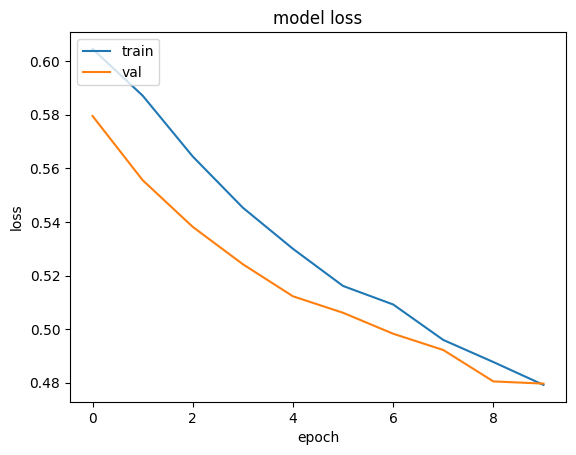

In [1715]:
import matplotlib.pyplot as plt
%matplotlib inline
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Пример хорошего графика

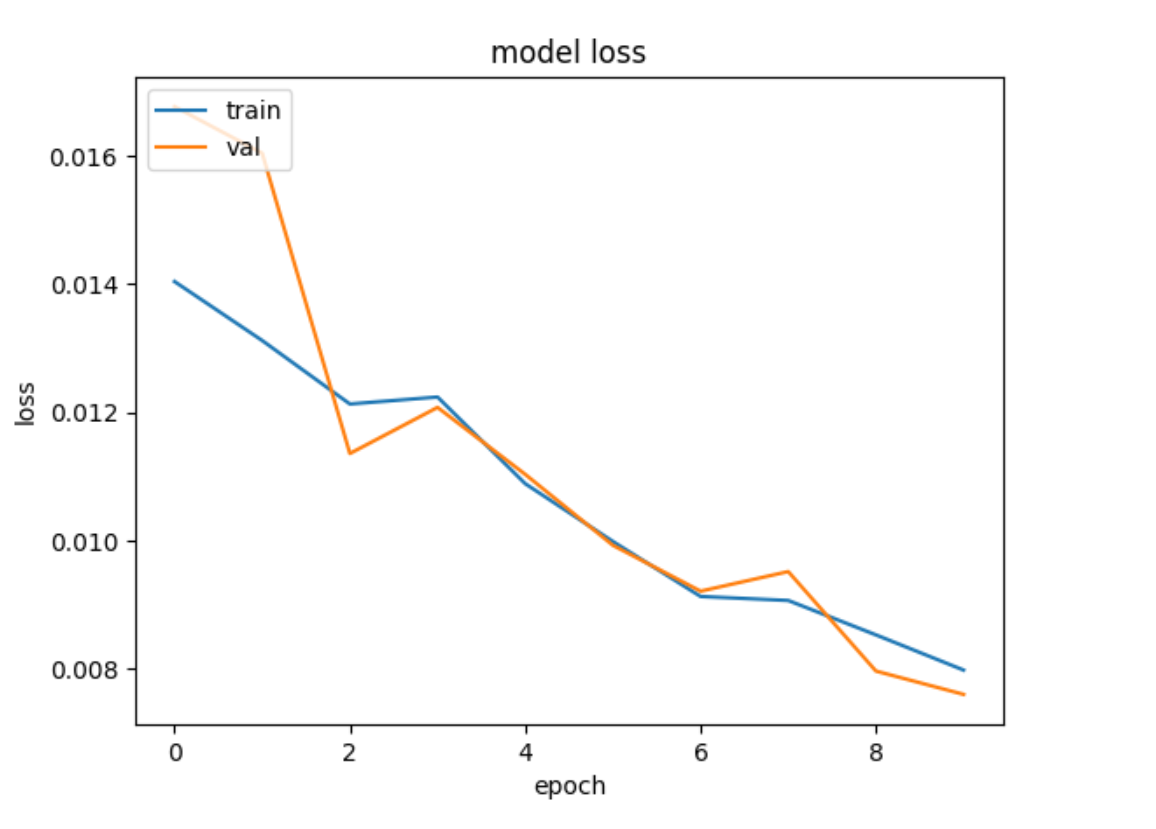

In [1716]:
from sklearn.model_selection import KFold, cross_val_predict
n_splits = 3
kf = KFold(n_splits=3)

# Получаем предсказания с использованием кросс-валидации
y_pred = cross_val_predict(RF, X, y, cv=kf)

# Вычисляем и выводим метрики
for fold, (train_index, val_index) in enumerate(kf.split(X)):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    RF.fit(X_train, y_train)
    y_pred = RF.predict(X_val)
    print(f"Обход {fold + 1}")
    print(classification_report(y_val, y_pred))
    print('\n')
    print("Матрица ошибок")
    cm = confusion_matrix(y_val, y_pred)
    print(cm)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 1750 out of 1750 | elapsed:    5.5s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed:    0.5s
[Parallel(n_jobs=4)]: Done 1750 out of 1750 | elapsed:    0.7s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent worke

Обход 1
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       191
           1       0.71      0.71      0.71       106

    accuracy                           0.79       297
   macro avg       0.78      0.78      0.78       297
weighted avg       0.79      0.79      0.79       297



Матрица ошибок
[[161  30]
 [ 31  75]]


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 1750 out of 1750 | elapsed:    5.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed:    0.5s
[Parallel(n_jobs=4)]: Done 1750 out of 1750 | elapsed:    0.8s finished


Обход 2
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       169
           1       0.85      0.73      0.79       128

    accuracy                           0.83       297
   macro avg       0.83      0.82      0.82       297
weighted avg       0.83      0.83      0.83       297



Матрица ошибок
[[152  17]
 [ 34  94]]


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done 1750 out of 1750 | elapsed:    5.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed:    0.5s


Обход 3
              precision    recall  f1-score   support

           0       0.82      0.97      0.89       189
           1       0.92      0.63      0.75       108

    accuracy                           0.85       297
   macro avg       0.87      0.80      0.82       297
weighted avg       0.86      0.85      0.84       297



Матрица ошибок
[[183   6]
 [ 40  68]]


[Parallel(n_jobs=4)]: Done 1750 out of 1750 | elapsed:    0.7s finished


Пришел к выводу следующему,что хоть и модель показывает приемлемый accuracy, есть многие вещи, которые я до сих пор не понимаю в матрице ошибок.


Возьмем 2 обход по кросс-валидации и сделаем следующие выводы:
1)модель предсказала, что погибнет, в итоге и вправду погиб(TN): 152
2)модель предсказала, что погиб, но на самом деле выжил(TP):34
3)модель предсказала, что выжил, но на самом деле погиб :( (FP): 17
4)модель предсказала, что выжил, в итоге и вправду выжил(TP): 94

Дополнительно можно сказать, что все проблемы,которые произошли в итоге этого задания были связаны с недостаточностью данных, что мотивирует использовать классификаторы как RF и CatBoost, в данном контексте они показали себя намного лучше.

В ходе работы я изучил способы работы с таблицей, а точнее фиче-инженирингу, как преобразовать таблицу в более понятный для модели образ, а также как работать с проблемами овер лифтинга и андер лифтинга.

Будем учиться!